# HMMER Domain Hit Analysis

This notebook analyzes HMMER search results across multiple genomes to identify patterns in protein domain distributions.

**Analysis includes:**
- Distribution of hits per genome
- E-value and score distributions
- Domain type analysis
- Genome-level comparisons
- Quality metrics

In [12]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import glob
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_style('whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11

print("✓ Libraries loaded successfully")

✓ Libraries loaded successfully


## 1. Load HMMER Results

Parse all TSV files from the HMMER output directory.

In [13]:
# UPDATE THIS PATH to your HMMER results directory
hmmer_results_dir = "/Users/daniel/Library/Mobile Documents/com~apple~CloudDocs/workspace/DarwinsRNAHunt/results/domain_hits"

def parse_hmmer_tsv(file_path):
    """
    Parse a HMMER tblout TSV file.
    
    Parameters:
    -----------
    file_path : str
        Path to the HMMER TSV file
    
    Returns:
    --------
    pd.DataFrame : Parsed HMMER results
    """
    hits = []
    
    with open(file_path, 'r') as f:
        for line in f:
            # Skip comment lines
            if line.startswith('#'):
                continue
            
            # Skip empty lines
            if not line.strip():
                continue
            
            # Split by whitespace
            parts = line.strip().split()
            
            # Extract relevant fields
            if len(parts) >= 19:
                hit = {
                    'target_name': parts[0],
                    'target_accession': parts[1],
                    'query_name': parts[2],
                    'query_accession': parts[3],
                    'full_evalue': float(parts[4]),
                    'full_score': float(parts[5]),
                    'full_bias': float(parts[6]),
                    'best_evalue': float(parts[7]),
                    'best_score': float(parts[8]),
                    'best_bias': float(parts[9]),
                    'exp': float(parts[10]),
                    'reg': int(parts[11]),
                    'clu': int(parts[12]),
                    'ov': int(parts[13]),
                    'env': int(parts[14]),
                    'dom': int(parts[15]),
                    'rep': int(parts[16]),
                    'inc': int(parts[17]),
                    'description': ' '.join(parts[18:])
                }
                hits.append(hit)
    
    return pd.DataFrame(hits)

# Find all TSV files
tsv_files = glob.glob(str(Path(hmmer_results_dir) / "*.tsv"))

print(f"Found {len(tsv_files)} TSV files")

# Parse all files
all_results = []
genome_hit_counts = {}

for tsv_file in tsv_files:
    genome_id = Path(tsv_file).stem.replace('_protdomain_hits', '')
    
    df = parse_hmmer_tsv(tsv_file)
    
    # Add genome ID column
    df['genome_id'] = genome_id
    
    # Track hit count
    genome_hit_counts[genome_id] = len(df)
    
    if len(df) > 0:
        all_results.append(df)

# Combine all results
if all_results:
    combined_df = pd.concat(all_results, ignore_index=True)
    print(f"\n✓ Loaded {len(combined_df)} total hits from {len(tsv_files)} genomes")
    print(f"✓ Genomes with hits: {len(all_results)}")
    print(f"✓ Genomes without hits: {len(tsv_files) - len(all_results)}")
else:
    print("⚠ No hits found in any files")
    combined_df = pd.DataFrame()

# Display first few rows
if not combined_df.empty:
    display(combined_df.head())

Task was destroyed but it is pending!
task: <Task pending name='Task-110' coro=<_async_in_context.<locals>.run_in_context_pre311() done, defined at /Users/daniel/Documents/workspace/miniconda3/envs/sequence_analysis/lib/python3.10/site-packages/ipykernel/utils.py:76> wait_for=<Task pending name='Task-111' coro=<_async_in_context.<locals>.preserve_context() running at /Users/daniel/Documents/workspace/miniconda3/envs/sequence_analysis/lib/python3.10/site-packages/ipykernel/utils.py:68> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /Users/daniel/Documents/workspace/miniconda3/envs/sequence_analysis/lib/python3.10/site-packages/zmq/eventloop/zmqstream.py:563]>
Task was destroyed but it is pending!
task: <Task pending name='Task-111' coro=<_async_in_context.<locals>.preserve_context() running at /Users/daniel/Documents/workspace/miniconda3/envs/sequence_analysis/lib/python3.10/site-packages/ipykernel/utils.py:68> cb=[Task.task_wakeup()]>


Found 336 TSV files

✓ Loaded 488 total hits from 336 genomes
✓ Genomes with hits: 321
✓ Genomes without hits: 15


,target_name,target_accession,query_name,query_accession,full_evalue,full_score,full_bias,best_evalue,best_score,best_bias,exp,reg,clu,ov,env,dom,rep,inc,description,genome_id
0,ALS64648.1,-,BLUF,PF04940.19,4.100000e-18,63.5,0.0,5.200000e-18,63.1,0.0,1.1,1,0,0,1,1,1,1,hypothetical protein AT395_06320 [Pandoraea ap...,GCA_001465595.2
1,VVD71553.1,-,BLUF,PF04940.19,2.100000e-19,67.6,0.0,3.500000e-19,66.8,0.0,1.4,1,0,0,1,1,1,1,hypothetical protein PMO31116_00637 [Pandoraea...,GCA_902459575.1
2,MBQ0961028.1,-,BLUF,PF04940.19,4.300000e-33,111.4,0.0,5.300000e-33,111.1,0.0,1.1,1,0,0,1,1,1,1,BLUF domain-containing protein [Ideonella sp. ...,GCA_018069755.1
3,MBQ0961153.1,-,BLUF,PF04940.19,2.100000e-27,93.2,0.0,2.500000e-27,93.0,0.0,1.1,1,0,0,1,1,1,1,BLUF domain-containing protein [Ideonella sp. ...,GCA_018069755.1
4,MBQ0958927.1,-,BLUF,PF04940.19,6.500000e-26,88.4,0.0,9.600000e-26,87.9,0.0,1.2,1,0,0,1,1,1,1,BLUF domain-containing protein [Ideonella sp. ...,GCA_018069755.1


## 2. Summary Statistics

In [14]:
if not combined_df.empty:
    print("HMMER Search Summary")
    print("=" * 60)
    print(f"Total genomes analyzed: {len(tsv_files)}")
    print(f"Genomes with hits: {len(all_results)} ({len(all_results)/len(tsv_files)*100:.1f}%)")
    print(f"Genomes without hits: {len(tsv_files) - len(all_results)} ({(len(tsv_files) - len(all_results))/len(tsv_files)*100:.1f}%)")
    print(f"\nTotal domain hits: {len(combined_df)}")
    print(f"Unique proteins with hits: {combined_df['target_name'].nunique()}")
    print(f"Unique query domains: {combined_df['query_name'].nunique()}")
    print()
    
    # Hits per genome statistics
    hit_counts = list(genome_hit_counts.values())
    print("\nHits per Genome Statistics:")
    print("=" * 60)
    print(f"Mean: {np.mean(hit_counts):.2f}")
    print(f"Median: {np.median(hit_counts):.2f}")
    print(f"Std Dev: {np.std(hit_counts):.2f}")
    print(f"Min: {np.min(hit_counts)}")
    print(f"Max: {np.max(hit_counts)}")
    print()
    
    # E-value statistics
    print("\nE-value Statistics:")
    print("=" * 60)
    print(f"Mean: {combined_df['full_evalue'].mean():.2e}")
    print(f"Median: {combined_df['full_evalue'].median():.2e}")
    print(f"Min: {combined_df['full_evalue'].min():.2e}")
    print(f"Max: {combined_df['full_evalue'].max():.2e}")
    print()
    
    # Score statistics
    print("\nScore Statistics:")
    print("=" * 60)
    print(f"Mean: {combined_df['full_score'].mean():.2f}")
    print(f"Median: {combined_df['full_score'].median():.2f}")
    print(f"Min: {combined_df['full_score'].min():.2f}")
    print(f"Max: {combined_df['full_score'].max():.2f}")
else:
    print("No hits to analyze")

HMMER Search Summary
Total genomes analyzed: 336
Genomes with hits: 321 (95.5%)
Genomes without hits: 15 (4.5%)

Total domain hits: 488
Unique proteins with hits: 488
Unique query domains: 1


Hits per Genome Statistics:
Mean: 1.45
Median: 1.00
Std Dev: 0.80
Min: 0
Max: 5


E-value Statistics:
Mean: 1.31e-08
Median: 1.40e-29
Min: 6.30e-34
Max: 4.90e-06


Score Statistics:
Mean: 93.87
Median: 100.05
Min: 24.60
Max: 114.10


## 3. Distribution of Hits per Genome

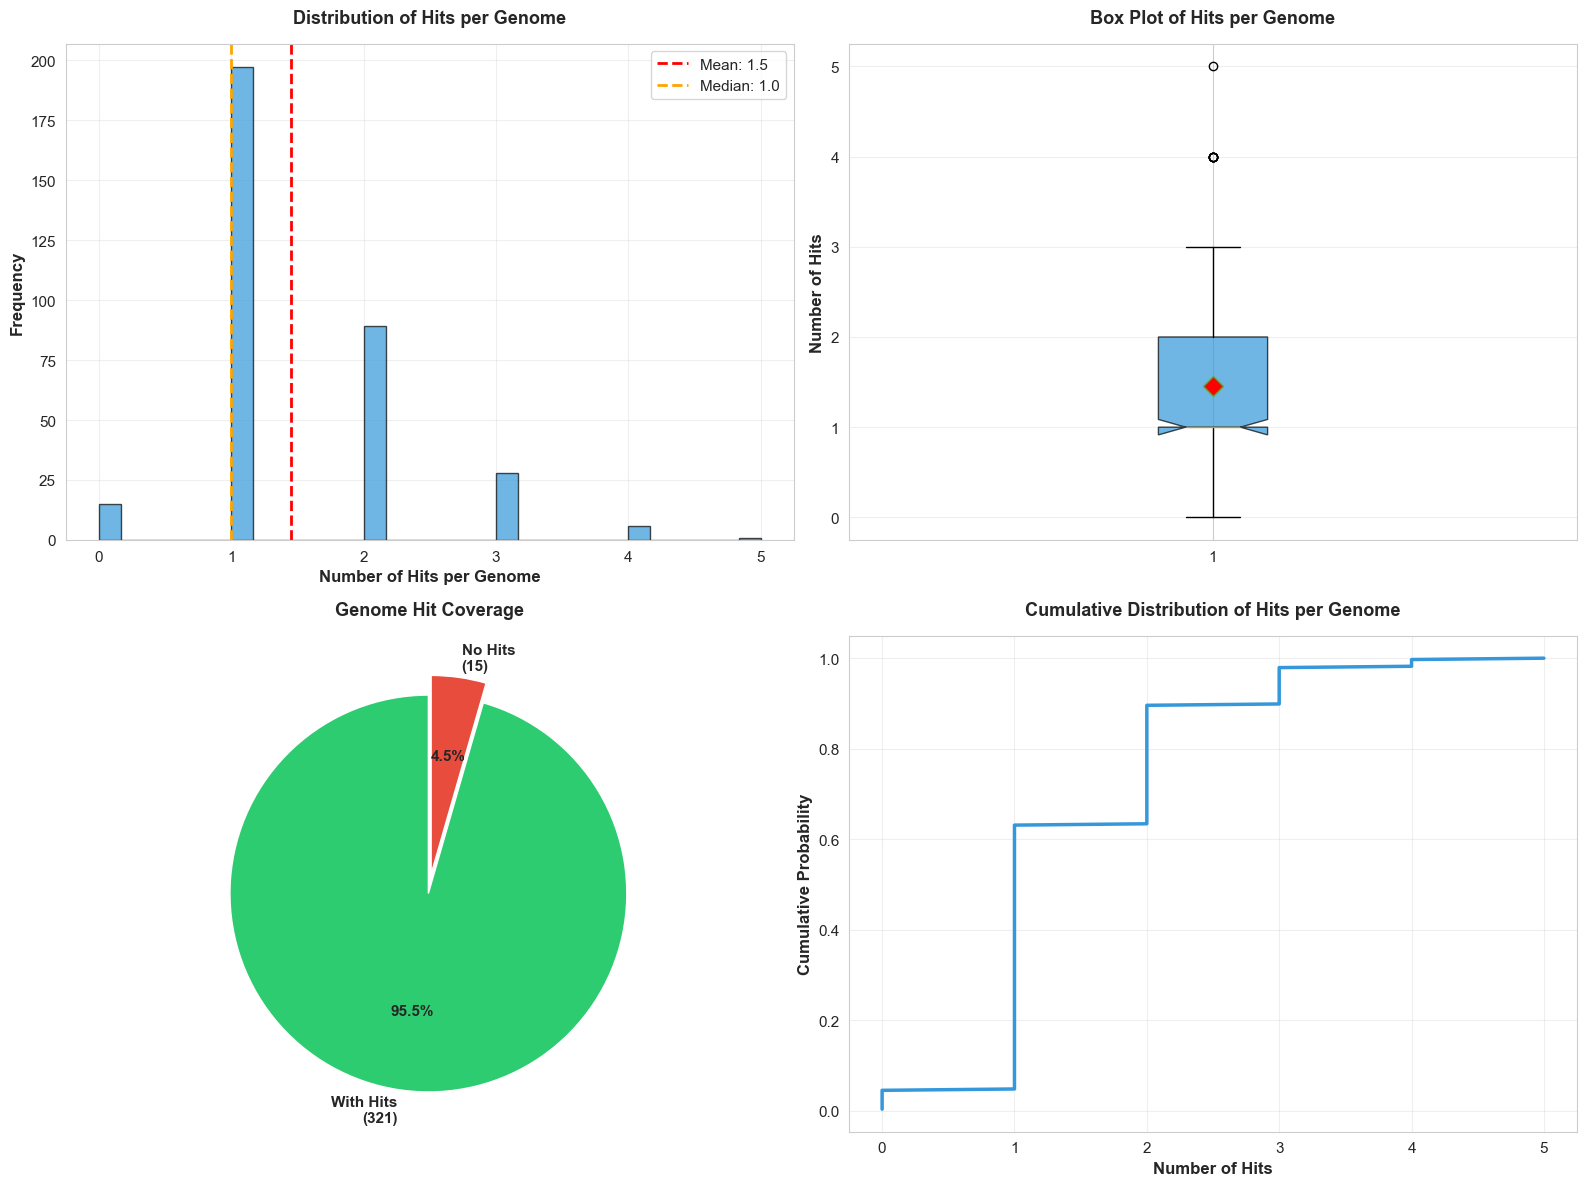

In [15]:
if genome_hit_counts:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # 3.1 Histogram of hits per genome
    ax1 = axes[0, 0]
    hit_counts_list = list(genome_hit_counts.values())
    ax1.hist(hit_counts_list, bins=30, color='#3498db', edgecolor='black', alpha=0.7)
    ax1.axvline(np.mean(hit_counts_list), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(hit_counts_list):.1f}')
    ax1.axvline(np.median(hit_counts_list), color='orange', linestyle='--', linewidth=2, label=f'Median: {np.median(hit_counts_list):.1f}')
    ax1.set_xlabel('Number of Hits per Genome', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Frequency', fontsize=12, fontweight='bold')
    ax1.set_title('Distribution of Hits per Genome', fontsize=13, fontweight='bold', pad=15)
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # 3.2 Box plot
    ax2 = axes[0, 1]
    bp = ax2.boxplot(hit_counts_list, vert=True, patch_artist=True,
                     notch=True, showmeans=True,
                     meanprops=dict(marker='D', markerfacecolor='red', markersize=10))
    bp['boxes'][0].set_facecolor('#3498db')
    bp['boxes'][0].set_alpha(0.7)
    ax2.set_ylabel('Number of Hits', fontsize=12, fontweight='bold')
    ax2.set_title('Box Plot of Hits per Genome', fontsize=13, fontweight='bold', pad=15)
    ax2.grid(True, alpha=0.3, axis='y')
    
    # 3.3 Pie chart: Genomes with/without hits
    ax3 = axes[1, 0]
    genomes_with_hits = len([v for v in genome_hit_counts.values() if v > 0])
    genomes_without_hits = len(tsv_files) - genomes_with_hits
    
    sizes = [genomes_with_hits, genomes_without_hits]
    labels = [f'With Hits\n({genomes_with_hits})', f'No Hits\n({genomes_without_hits})']
    colors = ['#2ecc71', '#e74c3c']
    explode = (0.05, 0.05)
    
    ax3.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%',
            startangle=90, explode=explode, textprops={'fontsize': 11, 'fontweight': 'bold'})
    ax3.set_title('Genome Hit Coverage', fontsize=13, fontweight='bold', pad=15)
    
    # 3.4 Cumulative distribution
    ax4 = axes[1, 1]
    sorted_hits = np.sort(hit_counts_list)
    y = np.arange(1, len(sorted_hits) + 1) / len(sorted_hits)
    ax4.plot(sorted_hits, y, linewidth=2.5, color='#3498db')
    ax4.set_xlabel('Number of Hits', fontsize=12, fontweight='bold')
    ax4.set_ylabel('Cumulative Probability', fontsize=12, fontweight='bold')
    ax4.set_title('Cumulative Distribution of Hits per Genome', fontsize=13, fontweight='bold', pad=15)
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("No data to plot")

## 4. Domain Type Analysis

Domain Type Distribution:
BLUF: 488 hits (100.00%)


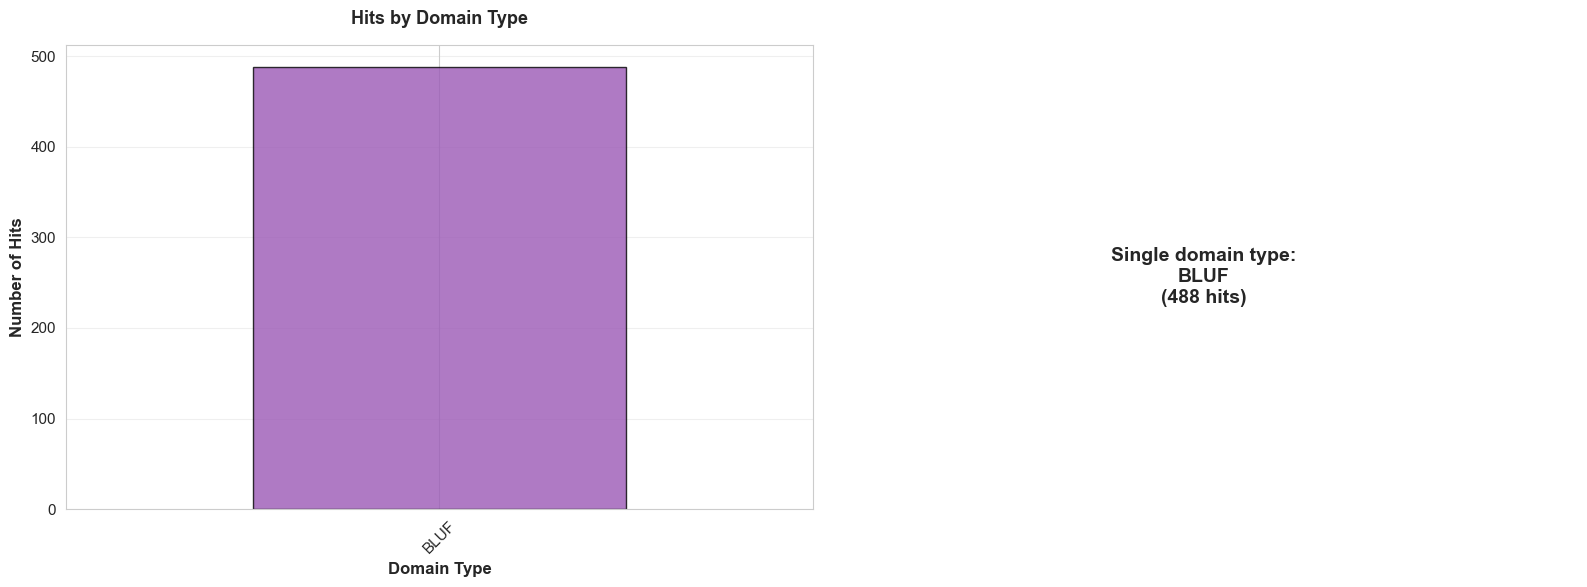

In [16]:
if not combined_df.empty:
    # Count hits by domain type
    domain_counts = combined_df['query_name'].value_counts()
    
    print("Domain Type Distribution:")
    print("=" * 60)
    for domain, count in domain_counts.items():
        print(f"{domain}: {count} hits ({count/len(combined_df)*100:.2f}%)")
    
    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Bar plot
    ax1 = axes[0]
    domain_counts.plot(kind='bar', ax=ax1, color='#9b59b6', edgecolor='black', alpha=0.8)
    ax1.set_xlabel('Domain Type', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Number of Hits', fontsize=12, fontweight='bold')
    ax1.set_title('Hits by Domain Type', fontsize=13, fontweight='bold', pad=15)
    ax1.tick_params(axis='x', rotation=45)
    ax1.grid(True, alpha=0.3, axis='y')
    
    # Pie chart (if multiple domain types)
    ax2 = axes[1]
    if len(domain_counts) > 1:
        ax2.pie(domain_counts.values, labels=domain_counts.index, autopct='%1.1f%%',
                startangle=90, textprops={'fontsize': 10})
        ax2.set_title('Domain Type Proportion', fontsize=13, fontweight='bold', pad=15)
    else:
        ax2.text(0.5, 0.5, f'Single domain type:\n{domain_counts.index[0]}\n({domain_counts.values[0]} hits)',
                 ha='center', va='center', fontsize=14, fontweight='bold')
        ax2.axis('off')
    
    plt.tight_layout()
    plt.show()
else:
    print("No domain data to analyze")

## 5. E-value and Score Distributions

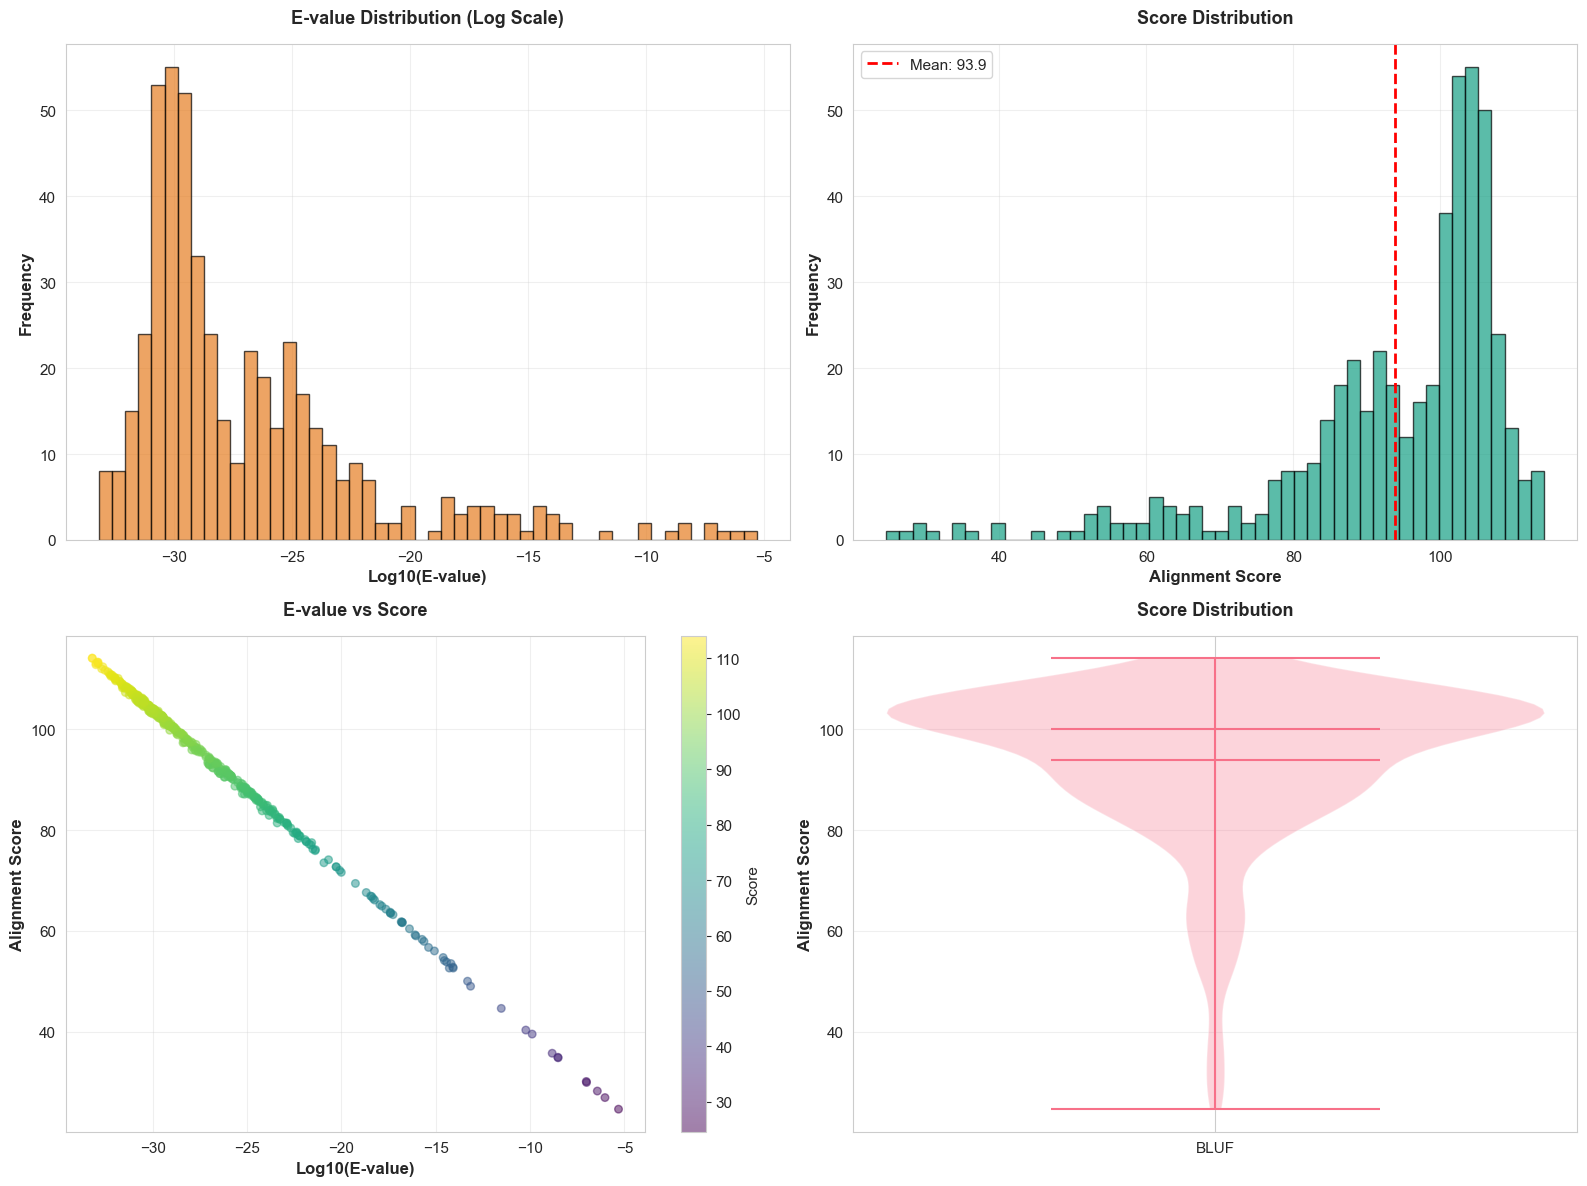

In [17]:
if not combined_df.empty:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # 5.1 E-value histogram (log scale)
    ax1 = axes[0, 0]
    ax1.hist(np.log10(combined_df['full_evalue']), bins=50, color='#e67e22', edgecolor='black', alpha=0.7)
    ax1.set_xlabel('Log10(E-value)', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Frequency', fontsize=12, fontweight='bold')
    ax1.set_title('E-value Distribution (Log Scale)', fontsize=13, fontweight='bold', pad=15)
    ax1.grid(True, alpha=0.3)
    
    # 5.2 Score histogram
    ax2 = axes[0, 1]
    ax2.hist(combined_df['full_score'], bins=50, color='#16a085', edgecolor='black', alpha=0.7)
    ax2.axvline(combined_df['full_score'].mean(), color='red', linestyle='--', 
                linewidth=2, label=f'Mean: {combined_df["full_score"].mean():.1f}')
    ax2.set_xlabel('Alignment Score', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Frequency', fontsize=12, fontweight='bold')
    ax2.set_title('Score Distribution', fontsize=13, fontweight='bold', pad=15)
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # 5.3 E-value vs Score scatter
    ax3 = axes[1, 0]
    scatter = ax3.scatter(np.log10(combined_df['full_evalue']), combined_df['full_score'],
                         alpha=0.5, c=combined_df['full_score'], cmap='viridis', s=30)
    ax3.set_xlabel('Log10(E-value)', fontsize=12, fontweight='bold')
    ax3.set_ylabel('Alignment Score', fontsize=12, fontweight='bold')
    ax3.set_title('E-value vs Score', fontsize=13, fontweight='bold', pad=15)
    plt.colorbar(scatter, ax=ax3, label='Score')
    ax3.grid(True, alpha=0.3)
    
    # 5.4 Violin plot of scores by domain type (if multiple domains)
    ax4 = axes[1, 1]
    if combined_df['query_name'].nunique() > 1:
        combined_df.boxplot(column='full_score', by='query_name', ax=ax4, patch_artist=True)
        ax4.set_xlabel('Domain Type', fontsize=12, fontweight='bold')
        ax4.set_ylabel('Alignment Score', fontsize=12, fontweight='bold')
        ax4.set_title('Score Distribution by Domain Type', fontsize=13, fontweight='bold', pad=15)
        plt.sca(ax4)
        plt.xticks(rotation=45)
        ax4.get_figure().suptitle('')  # Remove default title
    else:
        # Single domain - show violin plot
        parts = ax4.violinplot([combined_df['full_score']], positions=[1], showmeans=True, showmedians=True)
        ax4.set_ylabel('Alignment Score', fontsize=12, fontweight='bold')
        ax4.set_title('Score Distribution', fontsize=13, fontweight='bold', pad=15)
        ax4.set_xticks([1])
        ax4.set_xticklabels([combined_df['query_name'].iloc[0]])
        ax4.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
else:
    print("No data to plot")

## 6. Top Genomes by Hit Count

Top 20 Genomes by Hit Count:


,genome_id,hit_count
151,GCA_006438845.1,5
76,GCA_028023875.1,4
5,GCA_902712855.1,4
47,GCA_004016505.1,4
246,GCA_042665135.1,4
89,GCA_006974105.1,4
179,GCA_002083775.1,4
73,GCA_015159745.1,3
278,GCA_000477435.1,3
269,GCA_005403045.1,3



Bottom 20 Genomes by Hit Count:


,genome_id,hit_count
147,GCA_014652235.1,1
148,GCA_008693385.1,1
153,GCA_000013605.1,1
152,GCA_039872765.1,1
141,GCA_016093295.1,1
294,GCA_902859705.1,0
195,GCA_039673305.1,0
193,GCA_900078315.1,0
108,GCA_023509035.1,0
303,GCA_030188845.1,0


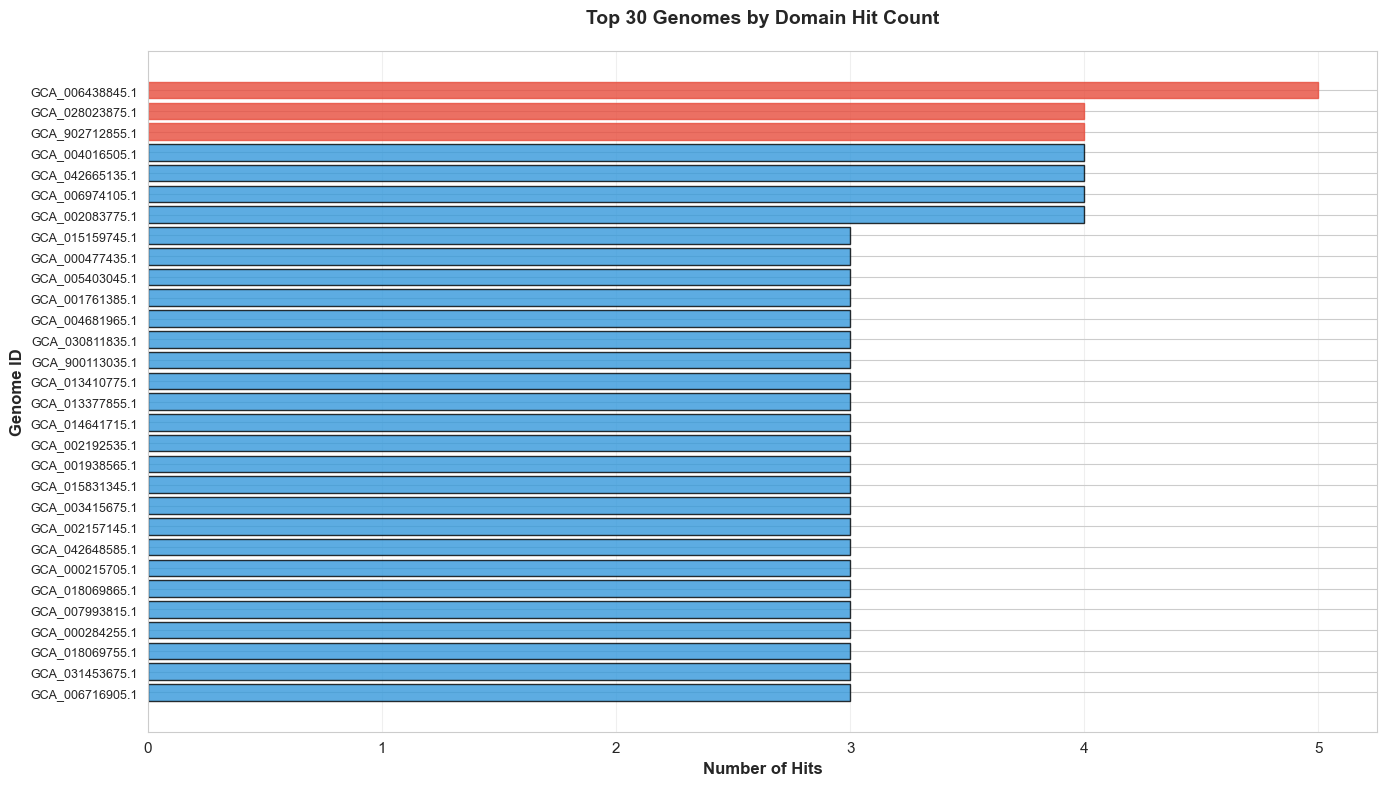

In [18]:
if genome_hit_counts:
    # Create DataFrame for easier manipulation
    genome_stats = pd.DataFrame([
        {'genome_id': k, 'hit_count': v} 
        for k, v in genome_hit_counts.items()
    ]).sort_values('hit_count', ascending=False)
    
    print("Top 20 Genomes by Hit Count:")
    print("=" * 60)
    display(genome_stats.head(20))
    
    print("\nBottom 20 Genomes by Hit Count:")
    print("=" * 60)
    display(genome_stats.tail(20))
    
    # Visualization - Top 30 genomes
    fig, ax = plt.subplots(figsize=(14, 8))
    top_30 = genome_stats.head(30)
    
    bars = ax.barh(range(len(top_30)), top_30['hit_count'], color='#3498db', edgecolor='black', alpha=0.8)
    
    # Color the top 3 differently
    for i in range(min(3, len(bars))):
        bars[i].set_color('#e74c3c')
    
    ax.set_yticks(range(len(top_30)))
    ax.set_yticklabels(top_30['genome_id'], fontsize=9)
    ax.set_xlabel('Number of Hits', fontsize=12, fontweight='bold')
    ax.set_ylabel('Genome ID', fontsize=12, fontweight='bold')
    ax.set_title('Top 30 Genomes by Domain Hit Count', fontsize=14, fontweight='bold', pad=20)
    ax.invert_yaxis()
    ax.grid(True, alpha=0.3, axis='x')
    
    plt.tight_layout()
    plt.show()
else:
    print("No genome data available")

## 7. Domain Co-occurrence Analysis

Analyze which domains tend to occur together in the same genomes.

In [19]:
if not combined_df.empty and combined_df['query_name'].nunique() > 1:
    # Create genome-domain matrix
    genome_domain_matrix = combined_df.groupby(['genome_id', 'query_name']).size().unstack(fill_value=0)
    
    # Convert to binary (presence/absence)
    genome_domain_binary = (genome_domain_matrix > 0).astype(int)
    
    # Calculate co-occurrence matrix
    cooccurrence = genome_domain_binary.T.dot(genome_domain_binary)
    
    # Visualization
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(cooccurrence, annot=True, fmt='d', cmap='YlOrRd', 
                square=True, cbar_kws={'label': 'Co-occurrence Count'}, ax=ax)
    ax.set_title('Domain Co-occurrence Matrix\n(Number of genomes with both domains)', 
                 fontsize=13, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()
    
    print("\nDomain Co-occurrence Summary:")
    print("=" * 60)
    display(cooccurrence)
elif not combined_df.empty:
    print("Only one domain type found - co-occurrence analysis not applicable")
else:
    print("No data for co-occurrence analysis")

Only one domain type found - co-occurrence analysis not applicable


## 8. Quality Metrics Analysis

Hit Quality Distribution:
High confidence (E-value < 1e-10): 479 (98.2%)
Medium confidence (1e-10 ≤ E-value < 1e-5): 9 (1.8%)


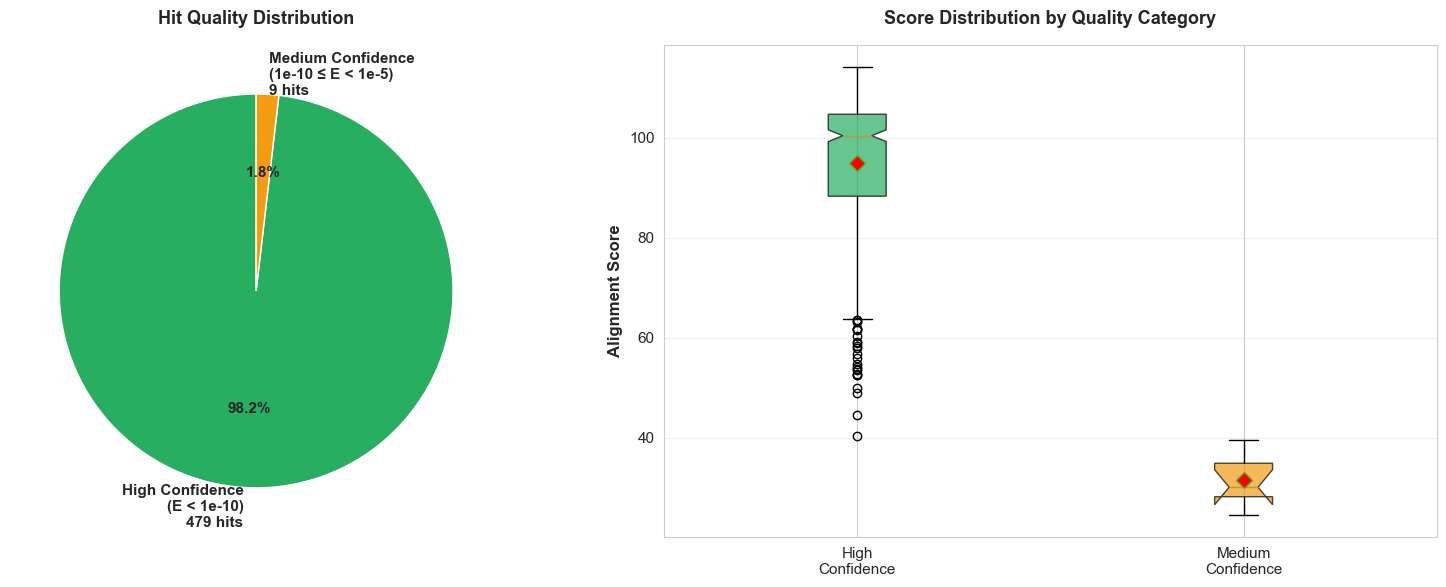

In [20]:
if not combined_df.empty:
    # Define quality thresholds
    high_quality = combined_df[combined_df['full_evalue'] < 1e-10]
    medium_quality = combined_df[(combined_df['full_evalue'] >= 1e-10) & (combined_df['full_evalue'] < 1e-5)]
    
    print("Hit Quality Distribution:")
    print("=" * 60)
    print(f"High confidence (E-value < 1e-10): {len(high_quality)} ({len(high_quality)/len(combined_df)*100:.1f}%)")
    print(f"Medium confidence (1e-10 ≤ E-value < 1e-5): {len(medium_quality)} ({len(medium_quality)/len(combined_df)*100:.1f}%)")
    
    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Pie chart of quality categories
    ax1 = axes[0]
    quality_counts = [len(high_quality), len(medium_quality)]
    quality_labels = [f'High Confidence\n(E < 1e-10)\n{len(high_quality)} hits',
                     f'Medium Confidence\n(1e-10 ≤ E < 1e-5)\n{len(medium_quality)} hits']
    colors = ['#27ae60', '#f39c12']
    
    ax1.pie(quality_counts, labels=quality_labels, colors=colors, autopct='%1.1f%%',
            startangle=90, textprops={'fontsize': 11, 'fontweight': 'bold'})
    ax1.set_title('Hit Quality Distribution', fontsize=13, fontweight='bold', pad=15)
    
    # Score comparison between quality categories
    ax2 = axes[1]
    score_data = [high_quality['full_score'], medium_quality['full_score']]
    bp = ax2.boxplot(score_data, labels=['High\nConfidence', 'Medium\nConfidence'],
                     patch_artist=True, notch=True, showmeans=True,
                     meanprops=dict(marker='D', markerfacecolor='red', markersize=8))
    
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    ax2.set_ylabel('Alignment Score', fontsize=12, fontweight='bold')
    ax2.set_title('Score Distribution by Quality Category', fontsize=13, fontweight='bold', pad=15)
    ax2.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
else:
    print("No data for quality analysis")

## 9. Export Results

In [21]:
# Export combined results
if not combined_df.empty:
    combined_df.to_csv('hmmer_combined_results.csv', index=False)
    print("✓ Combined results saved to 'hmmer_combined_results.csv'")

# Export genome statistics
if genome_hit_counts:
    genome_stats_df = pd.DataFrame([
        {'genome_id': k, 'hit_count': v} 
        for k, v in genome_hit_counts.items()
    ]).sort_values('hit_count', ascending=False)
    
    genome_stats_df.to_csv('genome_hit_statistics.csv', index=False)
    print("✓ Genome statistics saved to 'genome_hit_statistics.csv'")

# Export domain summary
if not combined_df.empty:
    domain_summary = combined_df.groupby('query_name').agg({
        'target_name': 'count',
        'full_evalue': ['mean', 'median', 'min', 'max'],
        'full_score': ['mean', 'median', 'min', 'max']
    }).round(4)
    
    domain_summary.columns = ['_'.join(col).strip() for col in domain_summary.columns.values]
    domain_summary = domain_summary.rename(columns={'target_name_count': 'total_hits'})
    domain_summary.to_csv('domain_summary_statistics.csv')
    print("✓ Domain summary saved to 'domain_summary_statistics.csv'")

print("\n✓ All exports complete!")

✓ Combined results saved to 'hmmer_combined_results.csv'
✓ Genome statistics saved to 'genome_hit_statistics.csv'
✓ Domain summary saved to 'domain_summary_statistics.csv'

✓ All exports complete!


## 10. Summary Report

In [22]:
print("="*80)
print("HMMER DOMAIN SEARCH ANALYSIS - FINAL REPORT")
print("="*80)

if genome_hit_counts:
    hit_counts_list = list(genome_hit_counts.values())
    print(f"\n📊 GENOME COVERAGE")
    print(f"   Total genomes analyzed: {len(tsv_files)}")
    print(f"   Genomes with hits: {len([v for v in hit_counts_list if v > 0])} ({len([v for v in hit_counts_list if v > 0])/len(tsv_files)*100:.1f}%)")
    print(f"   Genomes without hits: {len([v for v in hit_counts_list if v == 0])} ({len([v for v in hit_counts_list if v == 0])/len(tsv_files)*100:.1f}%)")

if not combined_df.empty:
    print(f"\n🎯 HIT STATISTICS")
    print(f"   Total domain hits: {len(combined_df):,}")
    print(f"   Unique proteins: {combined_df['target_name'].nunique():,}")
    print(f"   Unique domains: {combined_df['query_name'].nunique()}")
    print(f"   Mean hits per genome: {np.mean(hit_counts_list):.2f}")
    print(f"   Median hits per genome: {np.median(hit_counts_list):.2f}")
    
    print(f"\n📈 QUALITY METRICS")
    print(f"   Mean E-value: {combined_df['full_evalue'].mean():.2e}")
    print(f"   Mean alignment score: {combined_df['full_score'].mean():.2f}")
    high_conf = len(combined_df[combined_df['full_evalue'] < 1e-10])
    print(f"   High confidence hits (E < 1e-10): {high_conf} ({high_conf/len(combined_df)*100:.1f}%)")
    
    if combined_df['query_name'].nunique() > 1:
        print(f"\n🔍 DOMAIN DISTRIBUTION")
        for domain, count in combined_df['query_name'].value_counts().items():
            print(f"   {domain}: {count} hits ({count/len(combined_df)*100:.1f}%)")

print("\n" + "="*80)
print("Analysis complete! Check exported CSV files for detailed results.")
print("="*80)

HMMER DOMAIN SEARCH ANALYSIS - FINAL REPORT

📊 GENOME COVERAGE
   Total genomes analyzed: 336
   Genomes with hits: 321 (95.5%)
   Genomes without hits: 15 (4.5%)

🎯 HIT STATISTICS
   Total domain hits: 488
   Unique proteins: 488
   Unique domains: 1
   Mean hits per genome: 1.45
   Median hits per genome: 1.00

📈 QUALITY METRICS
   Mean E-value: 1.31e-08
   Mean alignment score: 93.87
   High confidence hits (E < 1e-10): 479 (98.2%)

Analysis complete! Check exported CSV files for detailed results.
